In [10]:
%matplotlib inline
# Cell 1
import warnings
warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from numpy.linalg import inv
from IPython.display import Image as IPImage

from scripts.shared.db_utils import db_connect
conn = db_connect()
print('connected')

connected


In [11]:
# Cell 2  — Load BasinATLAS scalars for all L06 basins
# pre_mm_syr  : annual precip (mm/yr)
# ari_ix_sav  : aridity index P/PET×100 (higher = wetter)
# tmp_dc_syr  : annual mean temp (°C×10 — divide by 10)
# NoData sentinel -9999 → NaN throughout.

scalar_sql = """
SELECT hybas_id,
       pre_mm_syr,
       ari_ix_sav,
       tmp_dc_syr
FROM   public.basin06
ORDER  BY hybas_id
"""
scalars = pd.read_sql(scalar_sql, conn)
scalars['hybas_id'] = scalars['hybas_id'].astype('int64')

# Mask NoData sentinel
for col in ['pre_mm_syr', 'ari_ix_sav', 'tmp_dc_syr']:
    scalars[col] = scalars[col].where(scalars[col] != -9999, other=np.nan)

# Temperature stored ×10
scalars['tmp_dc_syr'] = scalars['tmp_dc_syr'] / 10.0

print(f'Basins: {len(scalars):,}')
print(scalars[['pre_mm_syr','ari_ix_sav','tmp_dc_syr']].describe().round(2))

Basins: 16,397
       pre_mm_syr  ari_ix_sav  tmp_dc_syr
count    16397.00    16397.00    16397.00
mean       771.53       84.21       12.90
std        708.69      129.24       13.21
min          0.00        0.00      -23.90
25%        269.00       26.00        2.30
50%        545.00       65.00       17.10
75%       1090.00      104.00       24.70
max       6872.00     2101.00       31.10


In [12]:
# Cell 3  — Load monthly arrays + compute all derived seasonality vars
# Reuses circular-stats approach from WO7; adds tmp_seas_amp + tmp_concentration.
# NOTE: v_basin06_persist_rev2 stores monthly temps in °C already (not ×10).
#       Dividing by 10 here would produce amplitudes 10× too small.

TWO_PI = 2 * np.pi
THETA  = np.array([TWO_PI * m / 12 for m in range(12)])

def circ_conc_angle(W):
    """(N,12) weight matrix → (concentration, angle) each (N,); NaN where total==0."""
    total = W.sum(axis=1, keepdims=True)
    total = np.where(total == 0, np.nan, total)
    Rx = (W * np.cos(THETA)).sum(axis=1) / total[:, 0]
    Ry = (W * np.sin(THETA)).sum(axis=1) / total[:, 0]
    return np.sqrt(Rx**2 + Ry**2), np.arctan2(Ry, Rx)

arr_sql = """
SELECT hybas_id, pre_mm_monthly, tmp_dc_monthly
FROM   public.v_basin06_persist_rev2
ORDER  BY hybas_id
"""
raw = pd.read_sql(arr_sql, conn)
raw['hybas_id'] = raw['hybas_id'].astype('int64')
print(f'Array rows: {len(raw):,}')

PRE = np.array(raw['pre_mm_monthly'].tolist(), dtype=float)
TMP = np.array(raw['tmp_dc_monthly'].tolist(), dtype=float)  # already in °C

pre_conc, pre_angle = circ_conc_angle(PRE)

# Temperature: shift to non-negative before computing concentration
TMP_shifted = TMP - TMP.min(axis=1, keepdims=True)
tmp_conc, tmp_angle = circ_conc_angle(TMP_shifted)

# Phase offset: circular distance between precip and temp peaks (0–6 months)
delta          = np.abs(pre_angle - tmp_angle)
delta          = np.minimum(delta, TWO_PI - delta)
seas_phase_off = delta / TWO_PI * 12

# Temperature seasonal amplitude: monthly max – monthly min (°C)
tmp_seas_amp = TMP.max(axis=1) - TMP.min(axis=1)

derived = pd.DataFrame({
    'hybas_id':          raw['hybas_id'].values,
    'pre_concentration': pre_conc,
    'seas_phase_offset': seas_phase_off,
    'tmp_concentration': tmp_conc,
    'tmp_seas_amp':      tmp_seas_amp,
})

print(derived[['pre_concentration','seas_phase_offset','tmp_concentration','tmp_seas_amp']].describe().round(3))

Array rows: 16,397
       pre_concentration  seas_phase_offset  tmp_concentration  tmp_seas_amp
count          16338.000          16338.000          16397.000     16397.000
mean               0.412              1.987              0.450        19.824
std                0.230              1.844              0.080        13.743
min                0.000              0.000              0.014         0.400
25%                0.223              0.542              0.418         8.100
50%                0.388              1.116              0.467        17.600
75%                0.596              3.463              0.496        30.200
max                1.000              6.000              0.748        61.600


In [13]:
# Cell 4  — Merge all vars into one basin DataFrame; report completeness

basins = scalars.merge(derived, on='hybas_id', how='inner')
print(f'Merged basins: {len(basins):,}')

VARS_ALL = ['pre_mm_syr','ari_ix_sav','tmp_dc_syr',
            'pre_concentration','seas_phase_offset','tmp_concentration','tmp_seas_amp']

null_counts = basins[VARS_ALL].isna().sum()
print('\nNull counts per variable:')
print(null_counts)

Merged basins: 16,397

Null counts per variable:
pre_mm_syr            0
ari_ix_sav            0
tmp_dc_syr            0
pre_concentration    59
seas_phase_offset    59
tmp_concentration     0
tmp_seas_amp          0
dtype: int64


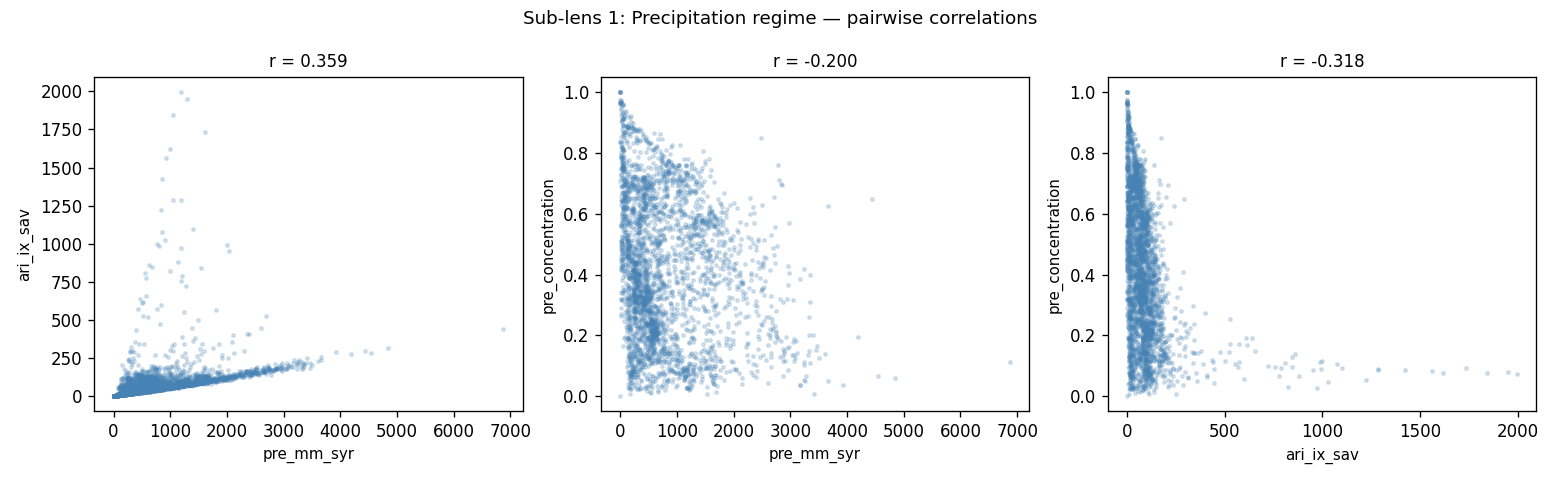

In [14]:
# Cell 5  — Sub-lens 1: Precipitation regime
# Candidate vars: pre_mm_syr, ari_ix_sav, pre_concentration
# Q: are precip and aridity correlated enough to warrant Mahalanobis?

PRECIP_VARS = ['pre_mm_syr', 'ari_ix_sav', 'pre_concentration']
df_p = basins[PRECIP_VARS].dropna()
print(f'Valid basins for precip lens: {len(df_p):,}')

corr_p = df_p.corr()
print('\nCorrelation matrix — Precipitation regime:')
print(corr_p.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor('white')
pairs = [('pre_mm_syr','ari_ix_sav'),
         ('pre_mm_syr','pre_concentration'),
         ('ari_ix_sav','pre_concentration')]
for ax, (x, y) in zip(axes, pairs):
    ax.set_facecolor('white')
    sample = df_p.sample(min(3000, len(df_p)), random_state=42)
    ax.scatter(sample[x], sample[y], alpha=0.2, s=4, color='steelblue')
    r = corr_p.loc[x, y]
    ax.set_xlabel(x, color='black', fontsize=9)
    ax.set_ylabel(y, color='black', fontsize=9)
    ax.set_title(f'r = {r:.3f}', color='black', fontsize=10)
    for spine in ax.spines.values(): spine.set_edgecolor('black')
    ax.tick_params(colors='black')

fig.suptitle('Sub-lens 1: Precipitation regime — pairwise correlations', color='black', fontsize=11)
fig.tight_layout()

OUT = Path(db_connect.__module__.replace('.', '/')).parent.parent.parent / 'output' / 'edop' / 'demo'
from scripts.shared import db_utils
OUT = Path(db_utils.__file__).parent.parent.parent / 'output' / 'edop' / 'demo'
OUT.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT / 'wo7a_precip_correlations.png', facecolor='white', dpi=120)
plt.close(fig)
display(IPImage(str(OUT / 'wo7a_precip_correlations.png')))

In [15]:
# Cell 6  — Sub-lens 1 validation: Rome + Timbuktu
# Mahalanobis distance on PRECIP_VARS; top-15 by name.

def mahal_dist_from(q_idx, X, VI):
    """Mahalanobis distance from row q_idx to all rows; NaN for rows with any NaN."""
    diff = X - X[q_idx]
    d2   = np.einsum('ij,jk,ik->i', diff, VI, diff)
    d2   = np.where(np.isnan(d2) | (d2 < 0), np.inf, d2)
    return np.sqrt(d2)

def ne_dist_from(q_idx, Xz):
    """Normalized Euclidean distance (z-scored) from row q_idx to all rows."""
    diff = Xz - Xz[q_idx]
    d    = np.sqrt(np.nansum(diff**2, axis=1))
    d[np.isnan(Xz).any(axis=1)] = np.inf
    return d

def build_lens(df, vars_, metric='mahalanobis'):
    """Build feature matrix + distance state for a lens variable set."""
    X = df[vars_].to_numpy(dtype=float)
    mask = ~np.isnan(X).any(axis=1)
    if metric == 'mahalanobis':
        cov  = np.cov(X[mask].T)
        VI   = inv(cov)
        return X, VI, mask
    else:  # euclidean
        mu = X[mask].mean(axis=0)
        sd = X[mask].std(axis=0)
        Xz = np.full_like(X, np.nan)
        Xz[mask] = (X[mask] - mu) / sd
        return X, Xz, mask

def validate(city, lat, lon, lens_vars, metric='mahalanobis', n=15):
    basin_sql = f"""
        SELECT hybas_id FROM public.basin06
        WHERE ST_Within(ST_SetSRID(ST_MakePoint({lon},{lat}),4326), geom)
        ORDER BY ST_Area(geom::geography) ASC LIMIT 1
    """
    q_hybas = int(pd.read_sql(basin_sql, conn).iloc[0, 0])
    q_idx   = basins.index[basins['hybas_id'] == q_hybas]
    if len(q_idx) == 0:
        print(f'{city}: basin {q_hybas} not in merged df'); return
    q_idx = int(q_idx[0])

    X    = basins[lens_vars].to_numpy(dtype=float)
    mask = ~np.isnan(X).any(axis=1)

    if metric == 'mahalanobis':
        cov = np.cov(X[mask].T)
        VI  = inv(cov)
        X_full = np.full(len(basins), np.inf)
        diff = X - X[q_idx]
        d2   = np.einsum('ij,jk,ik->i', diff, VI, diff)
        X_full = np.where(mask & (d2 >= 0), np.sqrt(d2), np.inf)
    else:
        mu = X[mask].mean(axis=0); sd = X[mask].std(axis=0)
        Xz = np.full_like(X, np.nan)
        Xz[mask] = (X[mask] - mu) / sd
        diff = Xz - Xz[q_idx]
        X_full = np.sqrt(np.nansum(diff**2, axis=1))
        X_full[~mask] = np.inf

    X_full[q_idx] = np.inf  # exclude self
    top_idx = np.argsort(X_full)[:n]
    result = basins.iloc[top_idx][['hybas_id'] + lens_vars].copy()
    result.insert(0, 'dist', X_full[top_idx].round(4))
    print(f'\n{city} (hybas_id={q_hybas}) — top {n} by {metric}:')
    print(result.to_string(index=False))

validate('Rome',     41.90,  12.50, PRECIP_VARS, metric='mahalanobis')
validate('Timbuktu', 16.82,  -2.98, PRECIP_VARS, metric='mahalanobis')


Rome (hybas_id=2060015610) — top 15 by mahalanobis:
  dist   hybas_id  pre_mm_syr  ari_ix_sav  pre_concentration
0.0307 7060447550         856          94           0.125852
0.0402 2060016020         842          90           0.137336
0.0403 7060498570         857          91           0.122315
0.0541 2060088830         811          90           0.138627
0.0554 7060437180         855          93           0.137755
0.0564 7060453940         838          88           0.141163
0.0633 7060492010         859          91           0.139721
0.0655 7060450950         883          95           0.124816
0.0715 7060490010         803          85           0.123558
0.0758 2060020730         866          95           0.112460
0.0771 7060494540         875          87           0.126631
0.0830 2060545490         891          97           0.118400
0.0848 2060547390         804          93           0.142231
0.0913 7060494360         823          87           0.112662
0.0915 5060077660         776   

In [16]:
# Cell 6b  — Precipitation regime: drop ari_ix_sav; use pre_mm_syr + pre_concentration (NE)
# Hypothesis: removing the moisture-balance variable recovers truer precipitation-pattern matches.

PRECIP_VARS_2 = ['pre_mm_syr', 'pre_concentration']

r2 = basins[PRECIP_VARS_2].dropna().corr().loc['pre_mm_syr', 'pre_concentration']
print(f'r(pre_mm_syr, pre_concentration) = {r2:.3f}')
print('Metric: Normalized Euclidean' if abs(r2) < 0.3 else f'WARNING: |r|={abs(r2):.3f} — consider Mahalanobis')

print()
validate('Rome',     41.90,  12.50, PRECIP_VARS_2, metric='euclidean')
validate('Timbuktu', 16.82,  -2.98, PRECIP_VARS_2, metric='euclidean')

r(pre_mm_syr, pre_concentration) = -0.200
Metric: Normalized Euclidean


Rome (hybas_id=2060015610) — top 15 by euclidean:
  dist   hybas_id  pre_mm_syr  pre_concentration
0.0095 7060345050         843           0.127741
0.0173 2060057880         825           0.129558
0.0191 7060343690         831           0.132680
0.0191 7060347220         849           0.130796
0.0211 7060030940         851           0.127017
0.0296 7060447550         856           0.125852
0.0296 3060014980         858           0.128809
0.0304 7060706280         830           0.135365
0.0323 7060383830         848           0.122215
0.0359 9060005360         814           0.132277
0.0379 7060345330         818           0.134894
0.0380 2060016020         842           0.137336
0.0385 7060048620         810           0.130072
0.0397 7060498570         857           0.122315
0.0441 6060017970         808           0.132511

Timbuktu (hybas_id=1060551560) — top 15 by euclidean:
  dist   hybas_id  pre_mm_syr  pre_con

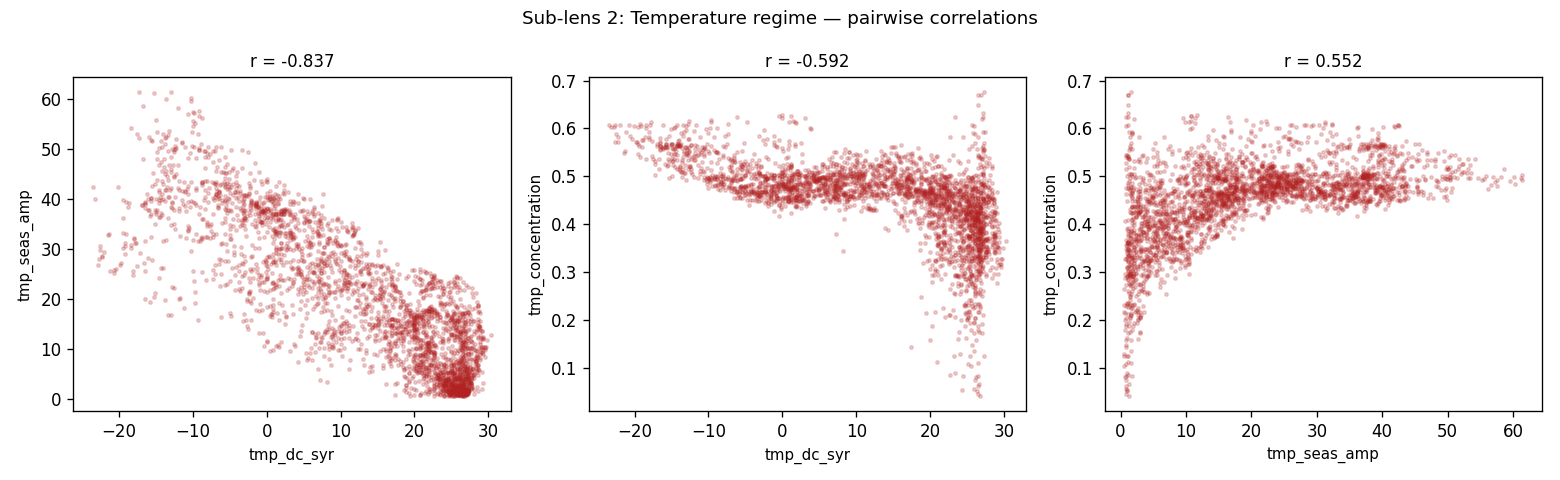

In [17]:
# Cell 7  — Sub-lens 2: Temperature regime
# Candidate vars: tmp_dc_syr (annual mean), tmp_seas_amp, tmp_concentration
# Q: are they correlated enough to warrant Mahalanobis?

TEMP_VARS = ['tmp_dc_syr', 'tmp_seas_amp', 'tmp_concentration']
df_t = basins[TEMP_VARS].dropna()
print(f'Valid basins for temp lens: {len(df_t):,}')

corr_t = df_t.corr()
print('\nCorrelation matrix — Temperature regime:')
print(corr_t.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor('white')
pairs_t = [('tmp_dc_syr','tmp_seas_amp'),
           ('tmp_dc_syr','tmp_concentration'),
           ('tmp_seas_amp','tmp_concentration')]
for ax, (x, y) in zip(axes, pairs_t):
    ax.set_facecolor('white')
    sample = df_t.sample(min(3000, len(df_t)), random_state=42)
    ax.scatter(sample[x], sample[y], alpha=0.2, s=4, color='firebrick')
    r = corr_t.loc[x, y]
    ax.set_xlabel(x, color='black', fontsize=9)
    ax.set_ylabel(y, color='black', fontsize=9)
    ax.set_title(f'r = {r:.3f}', color='black', fontsize=10)
    for spine in ax.spines.values(): spine.set_edgecolor('black')
    ax.tick_params(colors='black')

fig.suptitle('Sub-lens 2: Temperature regime — pairwise correlations', color='black', fontsize=11)
fig.tight_layout()
fig.savefig(OUT / 'wo7a_temp_correlations.png', facecolor='white', dpi=120)
plt.close(fig)
display(IPImage(str(OUT / 'wo7a_temp_correlations.png')))

In [18]:
# Cell 8  — Sub-lens 2 validation: Tbilisi + London
# Tbilisi: continental interior — expect high-amplitude, warm-summer matches
# London: maritime — expect equable, low-amplitude coastal/oceanic matches

validate('Tbilisi', 41.69, 44.80, TEMP_VARS, metric='mahalanobis')
validate('London',  51.50, -0.12, TEMP_VARS, metric='mahalanobis')


Tbilisi (hybas_id=2060616700) — top 15 by mahalanobis:
  dist   hybas_id  tmp_dc_syr  tmp_seas_amp  tmp_concentration
0.0751 4060619030         5.0          22.3           0.478168
0.0871 7060329370         4.2          22.8           0.483279
0.0875 4060039220         5.3          21.4           0.474947
0.0951 2060644030         5.2          22.2           0.486059
0.1050 2060517480         5.7          20.6           0.478683
0.1216 7060163190         5.9          21.0           0.470841
0.1292 2060520200         5.6          21.4           0.471001
0.1349 7060269780         4.4          21.9           0.488434
0.1351 7060261890         4.3          22.7           0.476925
0.1362 7060289980         3.8          22.7           0.489398
0.1477 2060517570         6.1          20.2           0.481776
0.1501 2060523590         6.3          20.2           0.482337
0.1514 4060594480         5.0          22.4           0.472998
0.1574 4060039270         3.6          22.5           0.485467

In [19]:
# Cell 9  — Sub-lens 3: Seasonal phase (confirm WO7 metric unchanged)
# Variables: pre_concentration, seas_phase_offset
# Expected: |r| < 0.3 → NE adequate (confirmed r=-0.121 in WO7)

PHASE_VARS = ['pre_concentration', 'seas_phase_offset']
df_ph = basins[PHASE_VARS].dropna()
r_ph  = df_ph.corr().loc['pre_concentration','seas_phase_offset']
print(f'r(pre_concentration, seas_phase_offset) = {r_ph:.3f}')
print('Metric: Normalized Euclidean (|r| < 0.3 → no Mahalanobis needed)' if abs(r_ph) < 0.3
      else f'WARNING: |r| = {abs(r_ph):.3f} — reconsider metric')

validate('San Francisco', 37.77, -122.42, PHASE_VARS, metric='euclidean')

r(pre_concentration, seas_phase_offset) = -0.121
Metric: Normalized Euclidean (|r| < 0.3 → no Mahalanobis needed)

San Francisco (hybas_id=7060013180) — top 15 by euclidean:
  dist   hybas_id  pre_concentration  seas_phase_offset
0.0187 6060008840           0.607080           5.616852
0.0261 7060574630           0.605234           5.692032
0.0290 2060088410           0.598935           5.614162
0.0304 6060009480           0.600558           5.690808
0.0350 2060770040           0.596554           5.656404
0.0371 2060735750           0.607362           5.579860
0.0373 2060816600           0.611963           5.677757
0.0449 2060745110           0.594636           5.618761
0.0455 2060741170           0.601091           5.564907
0.0460 7060012240           0.593879           5.642600
0.0462 2060741100           0.607553           5.725687
0.0495 2060783900           0.593095           5.637826
0.0521 2060745060           0.607596           5.737052
0.0577 2060100830           0.591179      

In [ ]:
# Cell 10  — A-summary: settled variable sets + metrics

summary = pd.DataFrame([
    {
        'lens_id':    'climate.precip',
        'label':      'Precipitation regime',
        'variables':  'pre_mm_syr, pre_concentration',
        'metric':     'euclidean',
        'r_max':      '-0.200',
        'validation': 'Timbuktu→Sahel ✓; Rome→similar-budget basins (L06 scale effect)',
    },
    {
        'lens_id':    'climate.temp',
        'label':      'Temperature regime',
        'variables':  'tmp_dc_syr, tmp_seas_amp, tmp_concentration',
        'metric':     'mahalanobis',
        'r_max':      '-0.837 (tmp_dc_syr↔tmp_seas_amp)',
        'validation': 'Tbilisi→cool continental Eurasia ✓; London→mild maritime ✓',
    },
    {
        'lens_id':    'climate.phase',
        'label':      'Seasonal phase',
        'variables':  'pre_concentration, seas_phase_offset',
        'metric':     'euclidean',
        'r_max':      f'{r_ph:.3f}',
        'validation': 'SF→Mediterranean cluster (CA + circum-Med Europe) ✓',
    },
])

pd.set_option('display.max_colwidth', 70)
display(summary)

print("""
Notes:
- ari_ix_sav dropped from climate.precip: moisture-balance variable (P/PET),
  not a pure precipitation variable; mixing dimensions corrupts label.
- tmp_dc_monthly in v_basin06_persist_rev2 is in °C (not ×10); no division
  needed for monthly array (scalar tmp_dc_syr in basin06 IS stored ×10).
- Mahalanobis mandatory for climate.temp (r=-0.837); NE adequate for the
  other two lenses.
""")